# BENCHMARK 1

Comparativa de los siguientes modelos con el datasets PASCAL VOC:
- U-NET
- SegFormer
- DeepLabV3
- SAM3 -> (Caso especial) Generalización.

## Importación de paquetes

In [1]:
import os
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import VOCSegmentation

import albumentations as A                      
#from torchvision import transforms

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.segmentation import MeanIoU

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation




## Configuración global

En la siguiente celda defino:

- La configuración global en formato diccionario.

- La media por canal (RGB) y la desviación estandar por canal (RGB) de las imágenes del dataset ImageNet, después de escalar sus píxeles al rango [0, 1].

- También defino la semilla para torch y numpy

In [2]:
CONFIG = {
    "epochs": 2,                                    # N° de pasadas del dataset completo
    "batch": 4,                                     # N° de imágenes por paso
    "lr": 5e-5,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
    "num_clases": 21,                               # Clases del dataset PascalVoc
    "img_size": 512,                                # Resolución de la imagen de entrada 512x512
    "seed": 42,                                     # Semilla para reproducibilidad
    "data": "../data/",                             # Ruta dataset
    "checkpoint_dir": "../checkpoints/benchmark1/",  # Ruta chechpoint
    "logs_dir": "../logs/benchmark1/",
    "mem_dir": "../memoria/benchmark1/"
}

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


# Crear carpetas necesarias
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(CONFIG["logs_dir"], exist_ok=True)
os.makedirs(CONFIG["mem_dir"], exist_ok=True)

In [3]:
#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Transformación para las imágenes de entrenamiento y de validación.

In [4]:
transform_train = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"],
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

transform_val = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"],
             interpolation=cv2.INTER_LINEAR,
             mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

## Dataset PASCAL (Pattern Analysis, Statistical Modelling and Computational Learning) VOC (Visual Object Classes)

In [5]:
class Dataset_VOC(Dataset):

    def __init__(self, root, conjunto="train", transform=None):
        self.dataset = VOCSegmentation(
            root=root,
            year="2012",
            image_set=conjunto,
            download=True
        )
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indice:int):
        image, mask = self.dataset[indice]

        image = np.array(image)
        mask = np.array(mask)

        # mask[mask == 255] = 0

        if self.transform:
            t = self.transform(image=image,mask=mask)
            image = t["image"]
            mask = t["mask"].long()

        return image, mask

Crear/cargar datasets para entrenamiento y validación.

In [6]:
train_data = Dataset_VOC(CONFIG["data"], "train", transform_train)
val_data = Dataset_VOC(CONFIG["data"], "val", transform_val)

Creación de DataLoader para entrenamiento y validación.

In [7]:
train_loader = DataLoader(
    train_data,                                         
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [8]:
print(f"N° imágenes de entrenamiento: {len(train_data)} imágenes | {len(train_loader)} batches")
print(f"N° imágenes de validación: {len(val_data)} imágenes | {len(val_loader)} batches")

N° imágenes de entrenamiento: 1464 imágenes | 366 batches
N° imágenes de validación: 1449 imágenes | 363 batches


En la siguiente celda se definen las clases del dataset Pascal Voc.

- Hay 20 clases de objetos + 1 para el fondo.


In [9]:
VOC_CLASES = [
    "background",
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car",
    "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

In [10]:
COLORMAP = [
    [0,0,0],       [128,0,0],     [0,128,0],     [128,128,0],
    [0,0,128],     [128,0,128],   [0,128,128],   [128,128,128],
    [64,0,0],      [192,0,0],     [64,128,0],    [192,128,0],
    [64,0,128],    [192,0,128],   [64,128,128],  [192,128,128],
    [0,64,0],      [128,64,0],    [0,192,0],     [128,192,0],
    [0,64,128]
]

Función para convertir la máscara (información de a que clase pertenece cada pixel) en una imágen RGB para poder visualizarla.

In [11]:
def colorear_mascara(mask):
    mask_color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in enumerate(COLORMAP):
        mask_color[mask == cls] = color
    return mask_color


Función para desnormalizar la imágen para poder visualizarla correctamente.

In [12]:
def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std = torch.tensor(STD).view(3,1,1)
    return (tensor * std + mean).clamp(0,1)

### Visualización de ejemplos

In [13]:
def visualizar_ejemplos(loader, n=4):
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow(colorear_mascara(masks[i].numpy()))
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos Pascal VOC 2012", fontsize=14)
    plt.tight_layout()
    plt.show()


Shape imágenes:  torch.Size([4, 3, 512, 512])
Shape máscaras:  torch.Size([4, 512, 512])
Clases únicas:   tensor([  0,   5,   8,  11,  15,  19, 255])


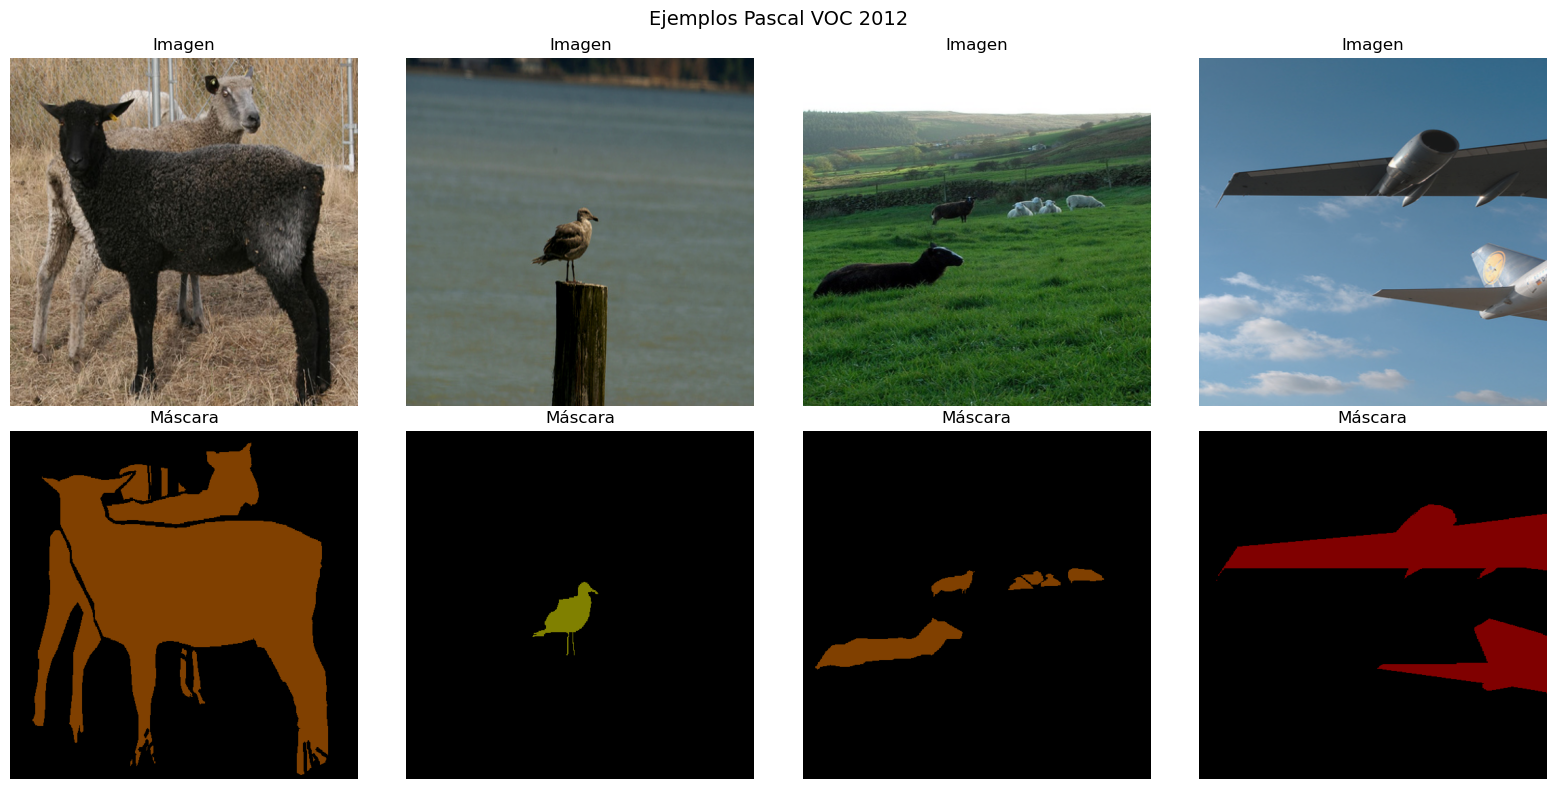

In [14]:
# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")
print(f"Shape máscaras:  {masks.shape}")
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(train_loader)

## Definir modelos

In [15]:
# ── U-Net ──────────────────────────────────────
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_unet(model, images):
    return model(images)

print(f"** U-Net -> N° parámetros: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")
print("\n** Modelo U-Net cargado")

** U-Net -> N° parámetros: 32.5M

** Modelo U-Net cargado


In [16]:
# ── DeepLabV3+ ──────────────────────────────────
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_deeplabv3plus(model, images):
    return model(images)

print(f"\n** DeepLabV3Plus -> N° parámetros: {sum(p.numel() for p in deeplabv3plus.parameters())/1e6:.1f}M")
print("\n** Modelo DeepLabV3Plus cargado")


** DeepLabV3Plus -> N° parámetros: 26.7M

** Modelo DeepLabV3Plus cargado


In [17]:
# ── SegFormer ──────────────────────────────────
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=(CONFIG["img_size"], CONFIG["img_size"]),
        mode="bilinear",
        align_corners=False
    )

print(f"\n\n\n** SegFormer -> N° parámetros: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")
print("\n** Modelo SegFormer cargado")

[transformers] You passed `num_labels=21` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr




** SegFormer -> N° parámetros: 27.4M

** Modelo SegFormer cargado


### Definición de la función de pérdida

In [18]:
class perdidaDiceCE(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            ignore_index=255
        )
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, obj):
        return 0.5 * self.dice(pred, obj) + 0.5 * self.ce(pred, obj)

loss_fn = perdidaDiceCE()
print("-> Función de pérdida definida")

-> Función de pérdida definida


## Bucle de entrenamiento

In [ ]:
def entrenar_modelo(modelo, nombre, forward_fn):

    modelo = modelo.to(device)
    writer  = SummaryWriter(log_dir=f"../logs/benchmark1/{nombre}")

    miou_fn = MeanIoU(
        num_classes=CONFIG["num_clases"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["epochs"],
        eta_min=1e-6
    )

    historial = {
        "loss_train": [],
        "miou_val":   []
    }
    tiempo_entrenamiento = 0.0
    mejor_miou = 0.0
    

    for epoch in range(CONFIG["epochs"]):

        # Aquí empieza el entrenamiento de cada epoch
        inicio_epoch = time.time()
        # -- Train ---------------------------
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )

        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            preds = forward_fn(modelo, images)
            loss = loss_fn(preds, masks)
            loss.backward()
            optimizer.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        loss_media = loss_total / len(train_loader)

        

        # -- Validación ---------------------------
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)

        miou_val = miou_fn.compute().item()
        scheduler.step()    # disminuye learning rate.

        tiempo_epoch = (time.time() - inicio_epoch)/60 # tiempo del entrenamiento de cada epochs.
        # -- Sumar tiempo epoch ---------------------------
        tiempo_entrenamiento += tiempo_epoch    # Sumo tiempo de epoch en minutos.

        # -- Guardar historial ---------------------------
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)
        
        # -- TensorBoard ---------------------------
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val", miou_val, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
        writer.add_scalar("Tiempo/epoch", tiempo_epoch, epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | Loss: {loss_media:.4f} | mIoU: {miou_val*100:.2f}% | Tiempo: {tiempo_epoch:.4f} min")

        # -- Guardar mejor modelo ---------------------------
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save({
                "epoch":          epoch,
                "modelo":         modelo.state_dict(),
                "optimizer":      optimizer.state_dict(),
                "scheduler":      scheduler.state_dict(),
                "mejor_miou":     mejor_miou,
                "historial":      historial
            },
            f"{CONFIG['checkpoint_dir']}{nombre}_b1_checkpoint.pth"
            )
            print(f"  -- Guardado modelo {nombre} con mIoU = {mejor_miou*100:.2f}%")

    writer.close()
    
    print(f"\n\n-->>    {nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}% | Tiempo total de entrenamiento: {tiempo_entrenamiento:.2f} min   <<--")
    
    #--- Libero memoria VRAM ------------------
    modelo.cpu()
    del modelo
    del optimizer
    del scheduler
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    #--------------------------------
    
    return mejor_miou, historial, tiempo_entrenamiento

## Entrenamiento modelos

In [20]:
# Entrenar U-net
miou_unet, hist_unet, tiempo_unet = entrenar_modelo(
    unet, "unet", forward_unet
)

[unet] Epoch 1/2:   0%|          | 0/366 [00:00<?, ?it/s]

[unet] Epoch 01 | Loss: 1.1694 | mIoU: 11.65% | Tiempo: 1.9049 min
  -- Guardado modelo unet con mIoU = 11.65%


[unet] Epoch 2/2:   0%|          | 0/366 [00:00<?, ?it/s]

[unet] Epoch 02 | Loss: 0.7589 | mIoU: 14.51% | Tiempo: 1.8882 min
  -- Guardado modelo unet con mIoU = 14.51%


-->>    unet completado | Mejor mIoU: 14.51% | Tiempo total de entrenamiento: 3.7931 min   <<--


In [21]:
#Entrenar DeepLabV3Plus
miou_deeplabv3plus, hist_deeplabv3plus, tiempo_deeplabv3plus = entrenar_modelo(
    deeplabv3plus, "deeplabv3plus", forward_deeplabv3plus
)

[deeplabv3plus] Epoch 1/2:   0%|          | 0/366 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 01 | Loss: 0.9000 | mIoU: 17.88% | Tiempo: 1.6672 min
  -- Guardado modelo deeplabv3plus con mIoU = 17.88%


[deeplabv3plus] Epoch 2/2:   0%|          | 0/366 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 02 | Loss: 0.5176 | mIoU: 19.62% | Tiempo: 1.6660 min
  -- Guardado modelo deeplabv3plus con mIoU = 19.62%


-->>    deeplabv3plus completado | Mejor mIoU: 19.62% | Tiempo total de entrenamiento: 3.3332 min   <<--


In [22]:
# Entrenar SegFormer
miou_segformer, hist_segformer, tiempo_segformer = entrenar_modelo(
    segformer, "segformer", forward_segformer
)

[segformer] Epoch 1/2:   0%|          | 0/366 [00:00<?, ?it/s]

[segformer] Epoch 01 | Loss: 0.5310 | mIoU: 21.42% | Tiempo: 2.7937 min
  -- Guardado modelo segformer con mIoU = 21.42%


[segformer] Epoch 2/2:   0%|          | 0/366 [00:00<?, ?it/s]

[segformer] Epoch 02 | Loss: 0.1870 | mIoU: 22.55% | Tiempo: 2.7638 min
  -- Guardado modelo segformer con mIoU = 22.55%


-->>    segformer completado | Mejor mIoU: 22.55% | Tiempo total de entrenamiento: 5.5576 min   <<--


## Visualizacion datos de entrenamiento.

In [29]:
"""
ALMACENAR MEJOR mIoU ENTRENAMIENTO.
"""
mejor_unet={"Modelo":"U-Net", "Mejor mIoU(%) entrenamiento":round(miou_unet*100,2), "Tiempo entrenamiento":round(tiempo_unet,2)}
mejor_deeplabv3plus={"Modelo":"DeepLabV3plus", "Mejor mIoU(%) entrenamiento":round(miou_deeplabv3plus*100,2), "Tiempo entrenamiento":round(tiempo_deeplabv3plus,2)}
mejor_segformer={"Modelo":"SegFormer", "Mejor mIoU(%) entrenamiento":round(miou_segformer*100,2), "Tiempo entrenamiento":round(tiempo_segformer,2)}

res_mejor=[]
res_mejor.append(mejor_unet)
res_mejor.append(mejor_deeplabv3plus)
res_mejor.append(mejor_segformer)

t = pd.DataFrame(res_mejor)
display(t)
t.to_csv(CONFIG["mem_dir"]+"resultados_b1_entrenamiento.csv")

,Modelo,Mejor mIoU(%) entrenamiento,Tiempo entrenamiento
0,U-Net,14.51,3.79
1,DeepLabV3plus,19.62,3.33
2,SegFormer,22.55,5.56


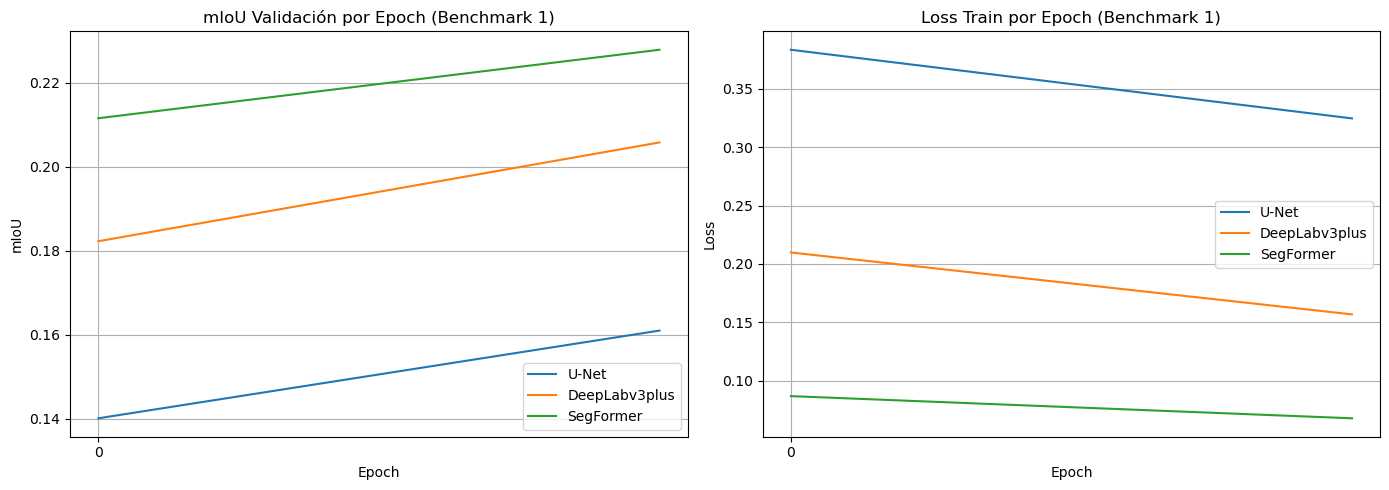

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch (Benchmark 1)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch (Benchmark 1)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../memoria/benchmark1/curvas_entrenamiento_b1.png", dpi=150)
plt.show()

## Evaluacion modelos.

Conjunto de validación para los modelos guardados. 

In [ ]:
conjunto_validacion = DataLoader(
    val_data,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [ ]:
"""
MODIFICAR FUNCION PARA EXTRAER SOLO PESOS DEL MODELO
"""

def evaluar_final(nombre, modelo, forward_fn):
    modelo.load_state_dict(
        torch.load(
            f"{CONFIG['checkpoint_dir']}{nombre}_b1_best.pth",
            map_location=device
        )
    )
    modelo.eval()
    modelo = modelo.to(device)

    miou_fn = MeanIoU(num_classes=CONFIG["num_clases"]).to(device)
    tiempos = []   # Lista para guardar tiempos de inferencia por imagen de cada batch.(FPS)
    n_params = sum(p.numel() for p in modelo.parameters()) / 1e6

    # Bucle para la evaluacion de los modelos.
    with torch.no_grad():
        for images, masks in conjunto_validacion:
            images = images.to(device)
            masks = masks.to(device)

            torch.cuda.synchronize()
            inicio = time.time()
            preds = forward_fn(modelo, images).argmax(dim=1)
            torch.cuda.synchronize()
            fin = time.time()

            tiempos.append(((fin - inicio) ))    # Tiempo por imágen.
            miou_fn.update(preds, masks)

    miou = miou_fn.compute().item()
    fps  = 1.0 / np.mean(tiempos)   # Frames por segundo.

    modelo.cpu()
    del modelo
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    return {"Modelo": nombre, "mIoU (%)": round(miou*100, 2), "FPS": round(fps, 1), "Params (M)": round(n_params, 1)}

In [ ]:
unet_val = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
deeplabv3plus_val = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=CONFIG["num_clases"]
)
segformer_val = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=21` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr

In [ ]:
# Evaluar todos los modelos.
resultados = []

res = evaluar_final("unet", unet_val, forward_unet)
resultados.append(res)

res = evaluar_final("deeplabv3plus", deeplabv3plus_val, forward_deeplabv3plus)
resultados.append(res)

res = evaluar_final("segformer", segformer_val, forward_segformer)
resultados.append(res)



# Tabla comparativa
df = pd.DataFrame(resultados).sort_values("mIoU (%)", ascending=False)
display(df)
df.to_csv("../memoria/benchmark1/resultados_finales_b1.csv", index=False)

,Modelo,mIoU (%),FPS,Params (M)
2,segformer,22.69,37.2,27.4
1,deeplabv3plus,20.02,66.8,26.7
0,unet,11.71,64.5,32.5


## Visualización de modelos entrenados.